# Task 2 : Analysis of Tesla Autopilot Data

## Import the necessary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder

## Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the file
data = pd.read_excel("/content/drive/MyDrive/vehicle_detection/vehicle_detection/Tesla Deaths.xlsx", header=1)

data.head()

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Excerpt Verifying Tesla Autopilot Deaths,Unnamed: 17,...,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,432.0,2024.0,2024-07-03 00:00:00,USA,NM,Tesla hit by drunk driver,1.0,1,-,-,...,-,-,https://web.archive.org/web/20240708022653/htt...,https://web.archive.org/web/20240708022653/htt...,https://web.archive.org/web/20240708022653/htt...,NaN,Tiger Gutierrez,NaN,NaN,NaN
1,431.0,2024.0,2024-06-29 00:00:00,USA,CA,Multi-vehicle accident,1.0,1,-,-,...,-,-,https://web.archive.org/web/20240617161723/htt...,https://web.archive.org/web/20240617161723/htt...,https://web.archive.org/web/20240617161723/htt...,NaN,Crystal Cruz Robledo,NaN,NaN,NaN
2,430.0,2024.0,2024-06-29 00:00:00,UK,-,Bus and Tesla collide,1.0,-,1,-,...,-,-,https://web.archive.org/web/20240708021323/htt...,https://web.archive.org/web/20240708021323/htt...,https://web.archive.org/web/20240708021323/htt...,NaN,NaN,NaN,NaN,NaN
3,429.0,2024.0,2024-06-27 00:00:00,USA,MA,"Tesla hits tree, catches on fire",1.0,1,-,-,...,-,-,https://web.archive.org/web/20240708020635/htt...,https://web.archive.org/web/20240708020635/htt...,https://web.archive.org/web/20240708020635/htt...,NaN,Sergi Kolesnick,NaN,NaN,NaN
4,428.0,2024.0,2024-06-20 00:00:00,USA,FL,"Tesla crashes into tree, goes up in flames",1.0,1,-,-,...,-,-,https://web.archive.org/web/20240708020832/htt...,https://web.archive.org/web/20240708020832/htt...,https://web.archive.org/web/20240708020832/htt...,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Check info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Case #                                    451 non-null    float64
 1   Year                                      451 non-null    float64
 2   Date                                      451 non-null    object 
 3   Country                                   451 non-null    object 
 4   State                                     451 non-null    object 
 5   Description                               452 non-null    object 
 6   Deaths                                    456 non-null    float64
 7   Tesla driver                              450 non-null    object 
 8   Tesla occupant                            450 non-null    object 
 9   Other vehicle                             450 non-null    object 
 10  Cyclists/ Peds                        

## Data Cleaning


### Fill Null values

In [ ]:
# Check for null values
data.isnull().sum()

,0
Case #,14
Year,14
Date,14
Country,14
State,14
Description,13
Deaths,9
Tesla driver,15
Tesla occupant,15
Other vehicle,15


In [ ]:
# Drop the na in the columns year as thos cannot be substitited and could be recurring
data = data.dropna(how='all')

In [ ]:
# Remove all null values in year
data = data.loc[data["Year"].notna()]

In [ ]:
# Replace - in columns with none

boolean_columns = ['Tesla driver', 'Tesla occupant', 'Other vehicle', 'Cyclists/ Peds', 'TSLA+cycl / peds',
                   'Autopilot claimed', 'Reported in NHTSA SGO', 'Verified Tesla Autopilot Deaths']
for col in boolean_columns:
    data[col] = data[col].replace({'-': 0, '1': 1}).fillna(0)


In [ ]:
# Delete Deceased and Note and source and ...

to_drop = ["Deceased 1", "Deceased 2", "Deceased 3", "Deceased 4", "Note", "Source", "...", "Unnamed: 17"]

data = data.drop(to_drop, axis=1)




In [ ]:
# Verify cleanliness of data
print(data.isnull().sum())

data.head()

Case #                                      0
Year                                        0
Date                                        0
Country                                     0
State                                       0
Description                                 0
Deaths                                      0
Tesla driver                                0
Tesla occupant                              0
Other vehicle                               0
Cyclists/ Peds                              0
TSLA+cycl / peds                            0
Model                                       0
Autopilot claimed                           0
Reported in NHTSA SGO                       0
Verified Tesla Autopilot Deaths             0
Excerpt Verifying Tesla Autopilot Deaths    0
dtype: int64


,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Reported in NHTSA SGO,Verified Tesla Autopilot Deaths,Excerpt Verifying Tesla Autopilot Deaths
0,432.0,2024.0,2024-07-03 00:00:00,USA,NM,Tesla hit by drunk driver,1.0,1.0,0.0,0.0,0.0,1.0,-,0.0,0,0,-
1,431.0,2024.0,2024-06-29 00:00:00,USA,CA,Multi-vehicle accident,1.0,1.0,0.0,0.0,0.0,1.0,-,0.0,0,0,-
2,430.0,2024.0,2024-06-29 00:00:00,UK,-,Bus and Tesla collide,1.0,0.0,1.0,0.0,0.0,1.0,3,0.0,0,0,-
3,429.0,2024.0,2024-06-27 00:00:00,USA,MA,"Tesla hits tree, catches on fire",1.0,1.0,0.0,0.0,0.0,1.0,-,0.0,0,0,-
4,428.0,2024.0,2024-06-20 00:00:00,USA,FL,"Tesla crashes into tree, goes up in flames",1.0,1.0,0.0,0.0,0.0,1.0,-,0.0,0,0,-


###  Enforce datatypes

In [ ]:
# Convert data to datetime
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d', errors='coerce')
data['Year'] = data['Date'].dt.year

In [ ]:
# Remove bad datatypes
data['Model'] = data['Model'].replace({'S': 'Model S', 'X': 'Model X', 'Y': 'Model Y', 3: 'Model 3', '-': 'Unspecified'})
data['State'] = data['State'].replace({'-': 'Unspecified'})
data['Excerpt Verifying Tesla Autopilot Deaths'] = data['Excerpt Verifying Tesla Autopilot Deaths'].replace({'-': 0})
data['Verified Tesla Autopilot Deaths'] = data['Verified Tesla Autopilot Deaths'].replace({'-': 0, '- ':0})

In [ ]:
# Convert Deaths to numeric
data['Deaths'] = pd.to_numeric(data['Deaths'], errors='coerce').astype(int)

In [ ]:
# Verify clean data
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 451 entries, 0 to 450
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Case #                                    451 non-null    float64       
 1   Year                                      448 non-null    float64       
 2   Date                                      448 non-null    datetime64[ns]
 3   Country                                   451 non-null    object        
 4   State                                     451 non-null    object        
 5   Description                               451 non-null    object        
 6   Deaths                                    451 non-null    int64         
 7   Tesla driver                              451 non-null    float64       
 8   Tesla occupant                            451 non-null    float64       
 9   Other vehicle                        

## Data Visualization

In [ ]:
# Set styles
sns.set_style("whitegrid")
sns.set_palette("deep")

**Incidents over time**

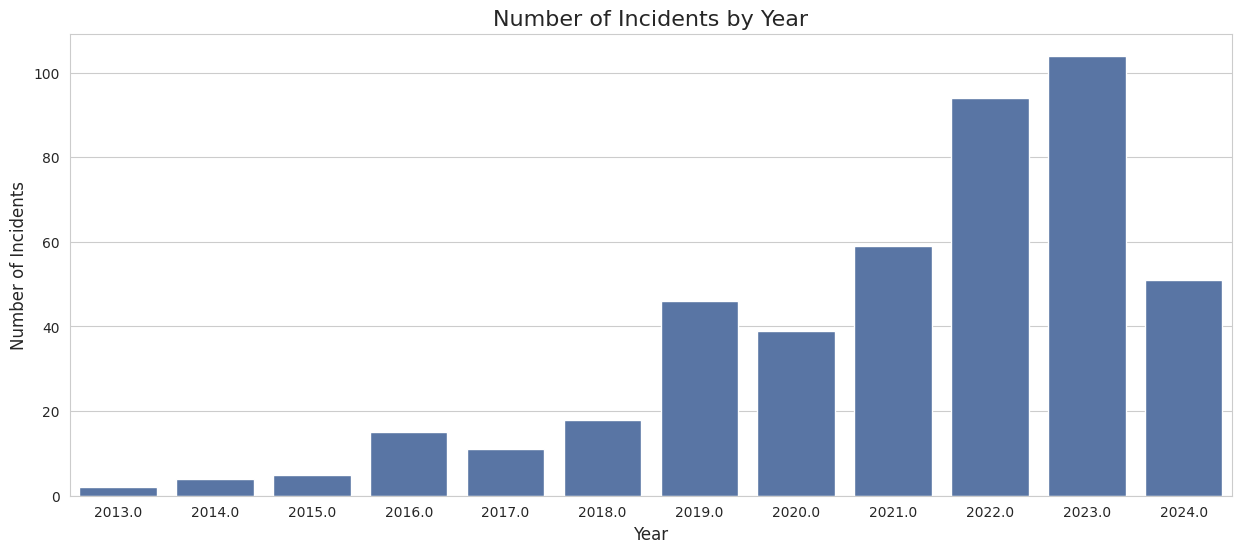

In [ ]:
# Incidents over time
plt.figure(figsize=(15, 6))
sns.barplot(x=data['Year'].value_counts().index, y=data['Year'].value_counts().values)
plt.title('Number of Incidents by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.show()

The most accidents seem to have happened in 2023 and 2022

*   List item

*   List item
*   List item


*   List item



**Deaths over time**

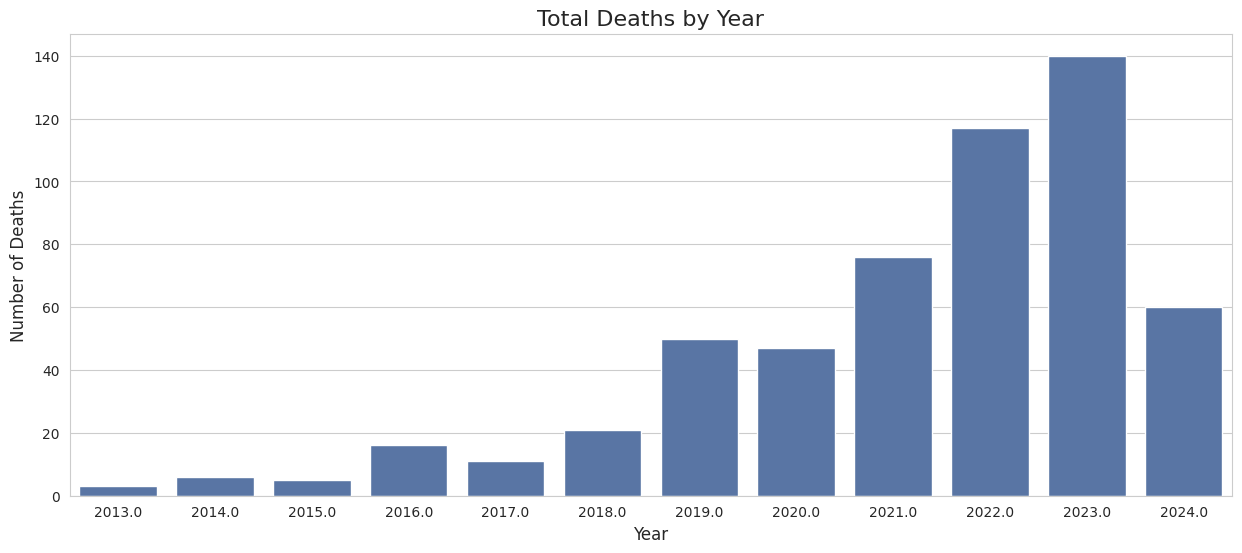

In [ ]:
plt.figure(figsize=(15, 6))
deaths_by_year = data.groupby('Year')['Deaths'].sum()
sns.barplot(x=deaths_by_year.index, y=deaths_by_year.values)
plt.title('Total Deaths by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.show()

Reflects the same as incidents over time

**Incidents by Country**

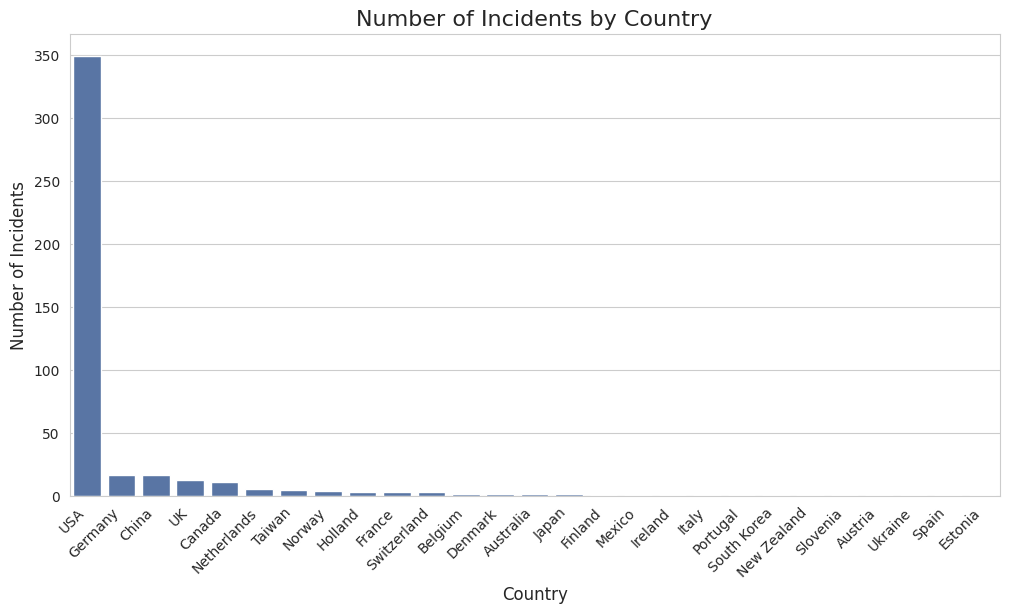

In [ ]:
plt.figure(figsize=(12, 6))
country_counts = data['Country'].value_counts()
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title('Number of Incidents by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

Most of the accidents were in the USA

**States in the US**

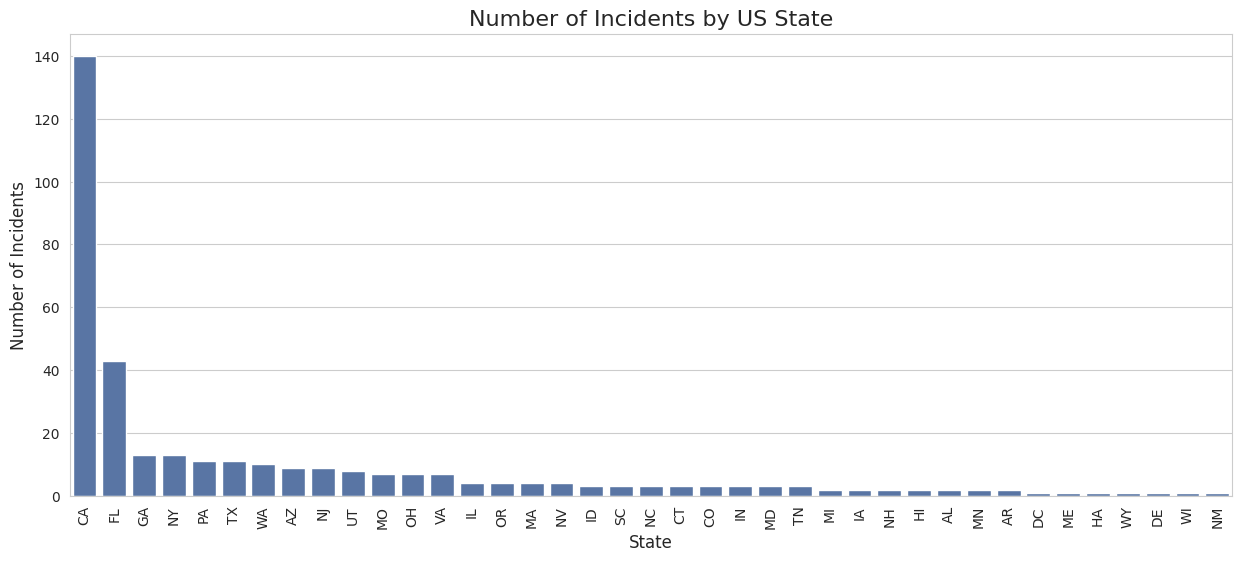

In [ ]:
us_incidents = data[data['Country'] == 'USA']
plt.figure(figsize=(15, 6))
state_counts = us_incidents['State'].value_counts()
sns.barplot(x=state_counts.index, y=state_counts.values)
plt.title('Number of Incidents by US State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=90)
plt.show()

Most of the accidents were in the state bof California

**Incidents by Tesla Models**

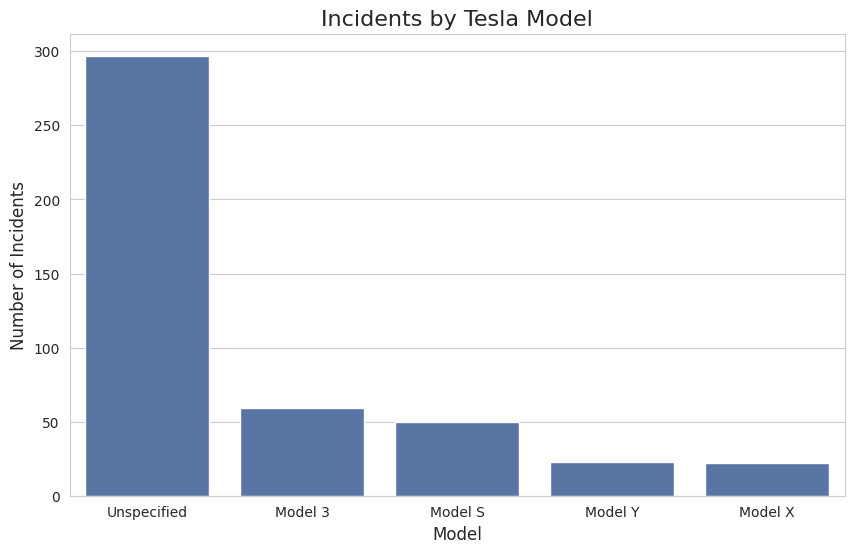

In [ ]:
plt.figure(figsize=(10, 6))
model_counts = data['Model'].value_counts()
sns.barplot(x=model_counts.index, y=model_counts.values)
plt.title('Incidents by Tesla Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.show()

Most of the incidents are unspecified on which model had the issue, but the next model that caused the most accidents was the Model 3

**Distribution of deaths per incident**

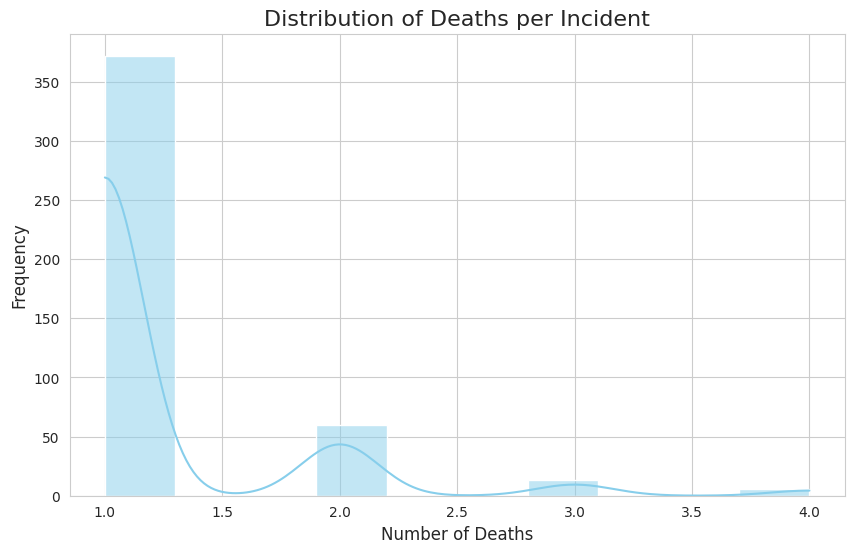

In [ ]:
# Distribution of deaths per incident
plt.figure(figsize=(10, 6))
sns.histplot(data['Deaths'], kde=True, color='skyblue')
plt.title('Distribution of Deaths per Incident', fontsize=16)
plt.xlabel('Number of Deaths', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Most of the number of deaths were one person

**Correlation**

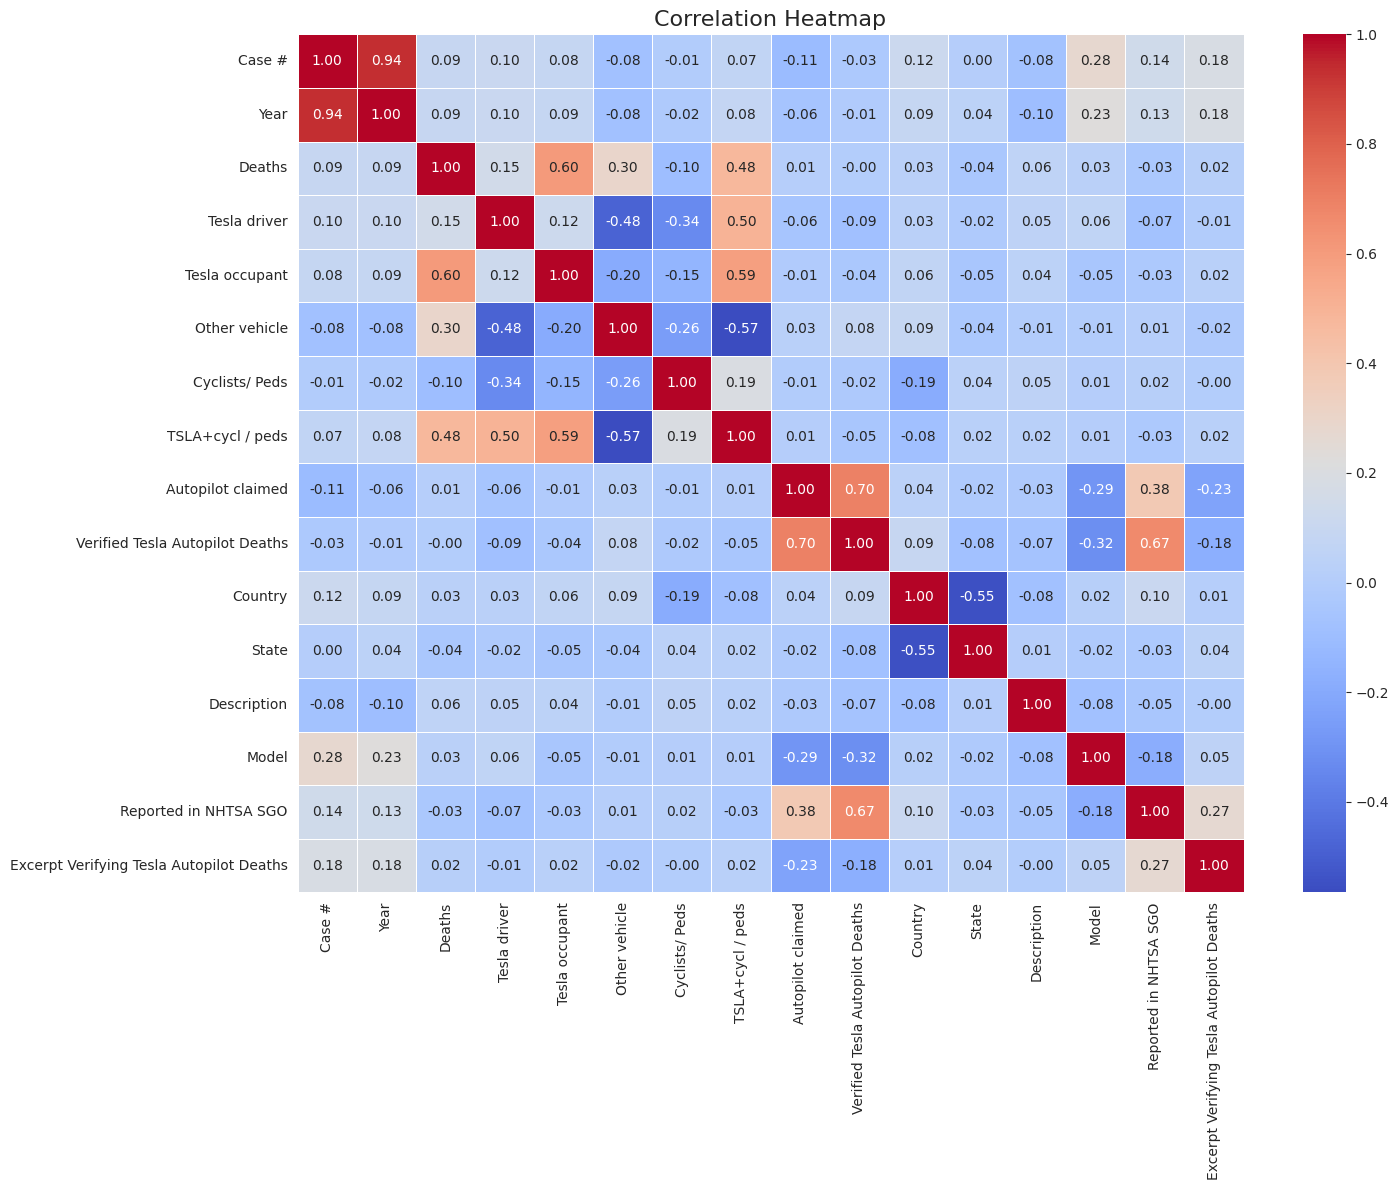

In [ ]:
datetime_col = 'Date'  # Adjust if your datetime column has a different name
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = data.select_dtypes(include=['object'])

# Step 2: Label Encoding
le = LabelEncoder()
df_encoded = data.copy().drop(datetime_col, axis=1)

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(data[col].astype(str))

# Step 3: Combine encoded categorical columns with numeric columns
columns_for_correlation = list(numeric_cols) + list(categorical_cols)

# Step 4: Calculate and plot correlation matrix
correlation_matrix = df_encoded[columns_for_correlation].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()


- **Occupant Fatalities**: Tesla occupant involvement is strongly correlated with higher death rates, suggesting increased risk for vehicle occupants in these incidents.
- **Autopilot Involvement**: There's a significant correlation between claimed and verified Autopilot-related deaths, confirming the reliability of Autopilot involvement claims.
- **Vehicle Interactions**: Incidents involving other vehicles are negatively correlated with Tesla driver fatalities and cyclist/pedestrian incidents, suggesting - **different risk patterns when multiple vehicles are involved.
- **Geographical Factors**: The strong negative correlation between State and Country likely reflects data coding practices for international incidents.
- **Model Variations**: There's a moderate negative correlation between vehicle model and verified Autopilot deaths, hinting at potential differences in Autopilot performance or usage across Tesla models.
- **Complex Fatality Factors**: Deaths show relatively weak correlations with most variables, indicating that fatalities in these incidents result from a complex interplay of factors.
- **Autopilot Safety Implications**: While Autopilot-related deaths correlate with claims and official reports, there's a slight negative correlation with driver fatalities, potentially suggesting some safety benefits.

**Seasonal Analysis**

In [ ]:
# Extract day of week
data['Day_of_Week'] = data['Date'].dt.day_name()

# Extract month and create season
data['Month'] = data['Date'].dt.month
data['Season'] = pd.cut(data['Month'],
                      bins=[0, 3, 6, 9, 12],
                      labels=['Winter', 'Spring', 'Summer', 'Fall'],
                      include_lowest=True)



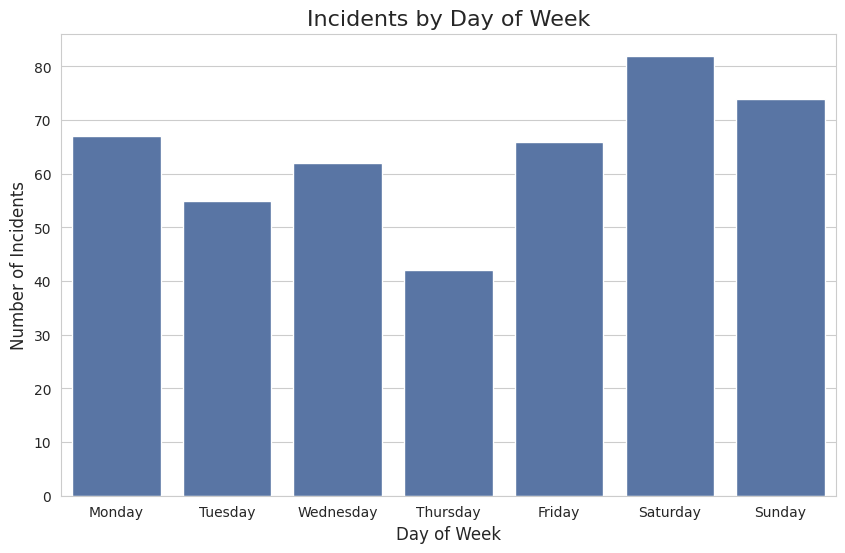

In [ ]:
# Incidents by day of week
plt.figure(figsize=(10, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = data['Day_of_Week'].value_counts().reindex(day_order)
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title('Incidents by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.show()

Most accidents happened over the weekend

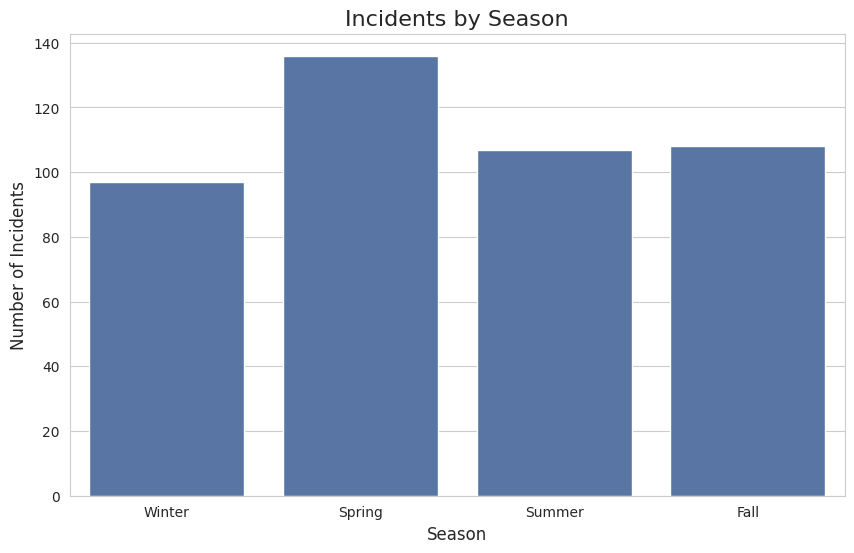

In [ ]:
# Seasonal analysis
plt.figure(figsize=(10, 6))
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_counts = data['Season'].value_counts().reindex(season_order)
sns.barplot(x=season_counts.index, y=season_counts.values)
plt.title('Incidents by Season', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.show()

Most accidents happened over spring

**Word cloud**

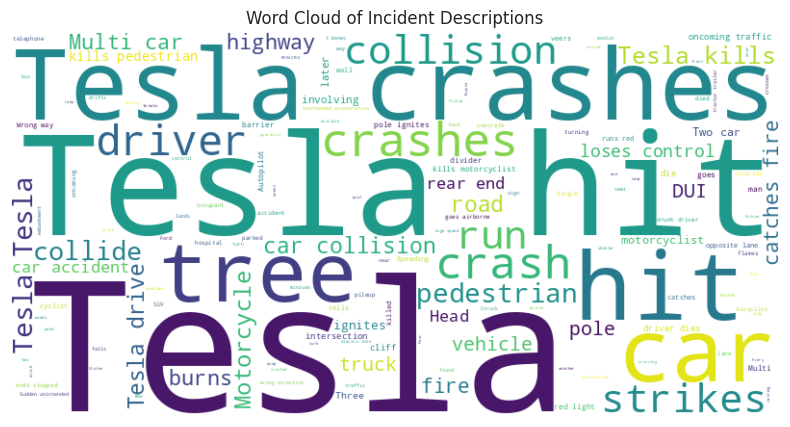

In [ ]:
try:
    from wordcloud import WordCloud
    text = ' '.join(data['Description'].dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Incident Descriptions')
    plt.show()
except ImportError:
    print("WordCloud not installed. Skipping word cloud visualization.")

**Key Statistics**

In [ ]:

print("\nKey Statistics:")
print(f"Total number of incidents: {len(data)}")
print(f"Total number of deaths: {data['Deaths'].sum()}")
print(f"Average deaths per incident: {data['Deaths'].astype(int).mean():.2f}")
print(f"Percentage of incidents involving Autopilot: {(data['Verified Tesla Autopilot Deaths'].astype(int).sum() / len(data)) * 100:.2f}%")



Key Statistics:
Total number of incidents: 451
Total number of deaths: 555
Average deaths per incident: 1.23
Percentage of incidents involving Autopilot: 9.76%


## Conclusion

Based on the key insights provided, here's a comprehensive summary of the Tesla incident dataset:

The dataset covers 451 Tesla-related incidents, resulting in a total of 555 deaths. On average, each incident resulted in 1.23 fatalities, indicating that most incidents involved single fatalities, with some resulting in multiple deaths.

Temporal and Seasonal Patterns:
- Incidents peaked in 2022 and 2023, suggesting a recent increase in Tesla-related accidents.
- Spring saw the highest number of incidents, with weekends being particularly prone to accidents.

Geographical Distribution:
- The majority of incidents occurred in the United States, with California reporting the highest number of accidents.
- There's a notable data coding difference between U.S. and international incidents, as reflected in the State-Country correlation.

Vehicle and Occupant Factors:
- Tesla Model 3 was involved in the most accidents among specified models, though many incidents lack model information.
- Tesla occupant involvement strongly correlates with higher death rates, indicating increased risk for vehicle occupants.
- Incidents involving other vehicles show different risk patterns, with fewer Tesla driver fatalities and cyclist/pedestrian incidents in such cases.

Autopilot Involvement:
- 9.76% of incidents involved Tesla's Autopilot feature.
- There's a strong correlation between claimed and verified Autopilot-related deaths, suggesting reliable reporting of Autopilot involvement.
- Interestingly, Autopilot use shows a slight negative correlation with driver fatalities, hinting at potential safety benefits despite its involvement in some incidents.

Fatality Patterns:
- Most incidents resulted in single fatalities.
- The weak correlation between deaths and most variables suggests that fatalities in these incidents result from a complex interplay of factors rather than single, dominant causes.

This summary reveals a complex picture of Tesla-related incidents. While certain patterns emerge, such as geographical hotspots and temporal trends, the data also highlights the multifaceted nature of these accidents. The role of Autopilot, while present in a significant minority of cases, presents a nuanced picture of both involvement in incidents and potential safety benefits. The dataset underscores the need for continued focus on vehicle safety, particularly for occupants, and further investigation into the factors contributing to accidents across different models and driving conditions.